In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
#Read the data_set 
df = pd.read_csv('dataset_for_yield_prediction.csv')

In [5]:
df.head()

,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


In [8]:
df.describe()

,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters)
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,254.963800,4.905400,2.398000,27.059200,56724.295600
std,139.417782,2.732689,1.438613,13.345789,27264.992053
min,12.500000,0.500000,0.140000,3.860000,5869.750000
25%,135.710000,2.437500,0.972500,16.190000,37818.152500
50%,281.980000,5.045000,2.330000,28.970000,54097.075000
75%,368.107500,6.885000,3.417500,37.860000,82240.032500
max,483.880000,9.960000,4.990000,48.020000,94754.730000


In [9]:
# Create a copy of the dataframe for visualization
df_viz = df.copy()


In [10]:
# Convert categorical variables to numerical using Label Encoding
categorical_columns = ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
df_encoded = df.copy()

In [11]:
# Create and fit separate label encoders for each categorical column
label_encoders = {}
for column in categorical_columns:
    label_encoders[column] = LabelEncoder()
    df_encoded[column] = label_encoders[column].fit_transform(df_encoded[column])

In [12]:

# Add derived features
df_encoded['Fertilizer_per_acre'] = df_encoded['Fertilizer_Used(tons)'] / df_encoded['Farm_Area(acres)']
df_encoded['Pesticide_per_acre'] = df_encoded['Pesticide_Used(kg)'] / df_encoded['Farm_Area(acres)']
df_encoded['Water_per_acre'] = df_encoded['Water_Usage(cubic meters)'] / df_encoded['Farm_Area(acres)']

In [13]:
# Separate features and target
X = df_encoded.drop(['Farm_ID', 'Yield(tons)'], axis=1)  # Keep all features including derived ones
y = df_encoded['Yield(tons)']


In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train multiple models
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

In [17]:
best_model = None
best_score = float('-inf')

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)

In [20]:

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n{name} Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
    


Gradient Boosting Model Performance:
Mean Squared Error: 318.27
R2 Score: -0.99
Mean Absolute Error: 14.89


In [22]:
# Cross-validation score
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

if r2 > best_score:
    best_score = r2
    best_model = model

print(f"\nBest model: {list(models.keys())[list(models.values()).index(best_model)]}")

Cross-validation scores: [-0.29331143 -0.0841716  -0.90291487 -4.7292007  -0.4340729 ]
Average CV score: -1.29 (+/- 3.48)

Best model: Gradient Boosting


In [23]:
# Feature Importance for the best model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)


Text(0.5, 1.0, 'Crop Type vs Yield')

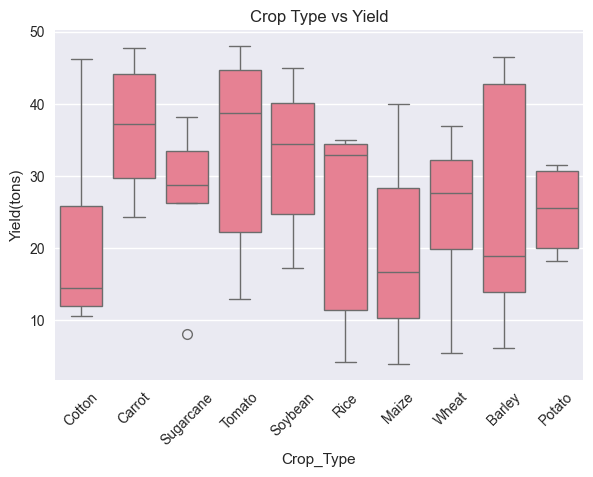

In [25]:
# Visualizations
plt.figure(figsize=(15, 10))

# 1. Crop Type vs Yield
plt.subplot(2, 2, 1)
sns.boxplot(x='Crop_Type', y='Yield(tons)', data=df_viz)
plt.xticks(rotation=45)
plt.title('Crop Type vs Yield')


Text(0.5, 1.0, 'Irrigation Type vs Yield')

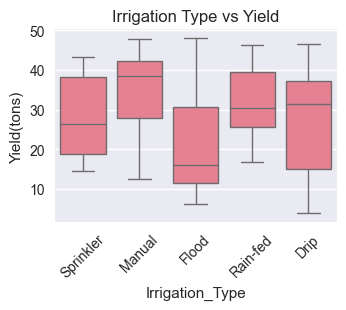

In [26]:
# 2. Irrigation Type vs Yield
plt.subplot(2, 2, 2)
sns.boxplot(x='Irrigation_Type', y='Yield(tons)', data=df_viz)
plt.xticks(rotation=45)
plt.title('Irrigation Type vs Yield')

Text(0.5, 1.0, 'Feature Importance')

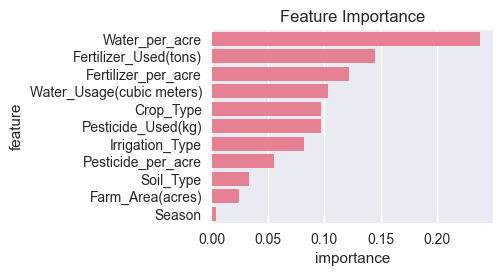

In [27]:
# 3. Feature Importance
plt.subplot(2, 2, 3)
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')

In [28]:
# 4. Correlation Heatmap (using only numeric columns)
plt.subplot(2, 2, 4)
numeric_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 
                'Yield(tons)', 'Water_Usage(cubic meters)']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('static/analysis_plots.png')
plt.close()

In [29]:
# Save the model and preprocessing objects
import joblib
joblib.dump(best_model, 'yield_prediction_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(label_encoders, 'label_encoders.joblib')

print("\nAnalysis complete! Check 'static/analysis_plots.png' for visualizations.")
print("Model and preprocessing objects have been saved.") 


Analysis complete! Check 'static/analysis_plots.png' for visualizations.
Model and preprocessing objects have been saved.
